For immersion: https://www.youtube.com/watch?v=sdBrscwwy_c

# 🌟 Operation NeuroNexus

Trondheim lies under the iron grip of SkyNet, an AI system that has seized control of the city's entire digital infrastructure. You and your team of elite hackers have been tasked with a crucial mission: infiltrate SkyNet's systems, decode its defenses, and liberate the city from its digital oppressor.

## 🎯 Mission Overview

Operation NeuroNexus consists of four independent, yet interconnected missions. Each mission targets a different aspect of SkyNet's infrastructure and requires you to apply various Supervised Learning techniques covered in this course.

## 📊 Mission Structure

1. Each mission has a specific task related to combating SkyNet.
2. Following the task description, you'll find a set of formal requirements that your solution must meet.
3. The primary measure of your success is the accuracy of your machine learning model.
4. After completing each task, you must answer a series of questions to demonstrate your understanding of the techniques used.

## 🧪 A Note on Test Data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each mission. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission Guidelines

- For each mission, provide your code solution and model results inside this notebook.
- Answer the follow-up questions in markdown format within this notebook. A few sentences is enough, no requirements for length of answers.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.


Good luck! The resistance is counting on you.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 🌞 Mission 1: Predicting SkyNet's Power Consumption

### 🎯 The Mission
Intelligence suggests that SkyNet has a critical weakness: **its power consumption**. We must understand its energy needs to plan a coordinated strike.

### 🧠 Your Task
Develop a predictive model to estimate SkyNet's power consumption based on its **Network Activity**.

**Goal**: Implement a **Linear Regression model using Gradient Descent, from scratch**.

Use `LinearRegression` class from `linear_regression.py` stored in this folder. Your task is to complete two functions: `fit` (find the optimal parameters of the regression) and `predict` (apply them to the test data).

> Note: The `%autoreload` IPython magic command allows instant updates from `linear_regression.py`.

### 📊 Formal Requirements
1. **Implementation**: 
   - Use standard Python libraries (numpy, math, pandas, etc.)
   - Implement gradient descent

2. **Discussion**:

   a. Visualize the fitted curve. Derive the resulting Energy consumption formula.
   
   b. Analyze prediction error distribution. What is an unbiased estimator?

---

2. discussion
   
    a. The resulting Energy consumption formula includes a slope which in this case, based on the prediction, is 3.2195. The bias, or intercept is 0.3247. The formula is EnergyConsumption(NetActivity) = 3.2195 * NetActivity + 0.3247.

    b. The prediction error distribution is relatively small and includes both positive and negative values. This means that the model both under- and overestimates the result. An unbiased estimator is an estimator that neither under- og overestimates. Since the mean residual is close to zero, the model is unbiased.



In [84]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
# Import your implementation
from linear_regression import LinearRegression, LogisticRegression, DecisionTreeBuilder, DecisionTreeDecrypter, RandomForestDecrypter, NexusRatingModel # <--- This is your implementation

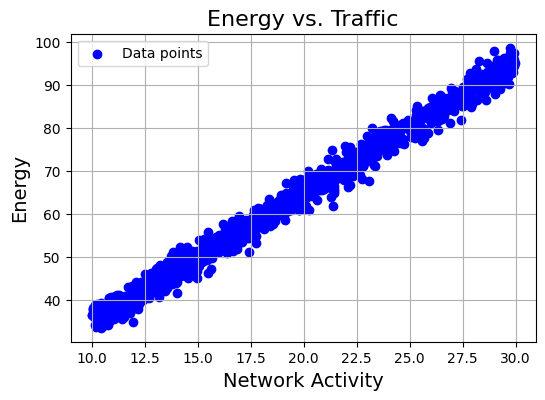

Average residual: 0.3448569780607956


In [89]:
# Load data
data = pd.read_csv('mission1.csv')

plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Energy vs. Traffic', fontsize=16)
plt.legend()
plt.show()


predictions = lr.predict(data['Net_Activity'])
residuals = data['Energy'].values - predictions
print("Average residual:", np.mean(residuals))

In [87]:
lr = LinearRegression()

lr.fit(data['Net_Activity'], data['Energy'])

lr.predict(data['Net_Activity'])

array([96.03454302, 59.52369697, 95.95267013, 32.74078152, 96.59139273,
       73.20868716, 35.41082248, 54.1829636 , 72.57628379, 54.33019109,
       64.04655003, 43.25391762, 46.79401413, 83.97605865, 73.70991043,
       39.19610936, 66.53840552, 95.25590059, 35.22222072, 58.18176264,
       39.59991703, 38.81325513, 90.45544208, 42.1020436 , 75.35272332,
       68.07793694, 47.10064444, 59.7225206 , 36.36498053, 87.02032037,
       95.90175336, 42.83580564, 55.31535644, 83.52520052, 54.63464347,
       70.9781844 , 35.92263755, 37.91948759, 79.79980032, 65.0484635 ,
       96.75412023, 85.18302615, 39.52485856, 41.92292911, 75.53318743,
       37.97325145, 47.74740516, 44.31757066, 46.27823877, 55.20358123,
       38.75363016, 58.39744528, 71.56007452, 35.94167346, 36.6028456 ,
       76.06833318, 43.04536074, 58.41143431, 85.78744967, 85.04916102,
       71.11305905, 46.47155797, 94.6420368 , 58.26446407, 39.09395667,
       85.09943731, 73.25284156, 63.80070168, 81.98466359, 85.48

## 🧠 Mission 2: Decoding SkyNet's signals

### 🌐 The Discovery
We've intercepted two types of signals that may determine SkyNet's next moves.

### 🎯 Your Mission
1. Evolve your linear regression into logistic regression
2. Engineer features to unravel hidden connections
3. Predict SkyNet's binary decisions (0 or 1) from paired signals

### 📊 Formal Requirements
1. **Implementation**: 
   - Use standard Python libraries
   - Implement gradient descent

2. **Performance**: Achieve at least 0.88 accuracy on the test set

3. **Discussion**:

   a. Explain poor initial performance and your improvements

   b. What is the model's inductive bias. Why is it important?

   c. Try to solve the problem using `sklearn.tree.DecisionTreeClassifier`. Can it solve the problem? Why/Why not?
   
   d. Plot the ROC curve

---

In [74]:
data = pd.read_csv('mission2.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

X = train[['x0', 'x1']].values
y = train['y'].values

dt = DecisionTreeBuilder()
dt.fit(X,y)

X_test = test[['x0', 'x1']].values
y_test = test['y'].values

acc = dt.accuracy(X, y)
print("Train accuracy: ", acc)

test_acc = dt.accuracy(X_test, y_test)
print("Test accuracy: ", test_acc)

Train accuracy:  0.964
Test accuracy:  0.916


2. Performance

The accuracy was 0.512 for training and 0.490 for testing. 

3. Discussion

   a. Linear regression works porly when modelling with a parabolic function. To solve this we can use feature engineering. We can create a new feature by transforming our data to a higher polynomial degree. 

   b. The models inductive bias is 0.0920. This is important because it tells us the the difference between the target and our predictions. This means a low bias is good.

   c. With a decision tree we get a test accuracy of 0.916, which is over 0.88. This means we solved the problem with the new model. The reason might be that the data was not large enough for logistic regression. Decision trees can be trained on smaller data sets.

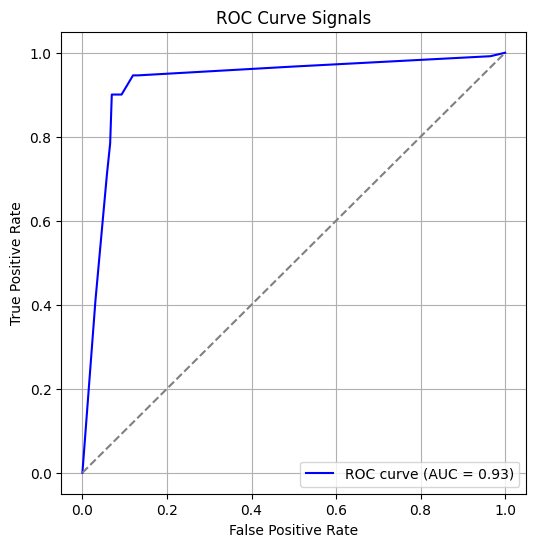

In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
y_prob = dt.model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Signals')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 🌆 Mission 3: CyberGuard

### 🌐 The Discovery
SkyNet's drone communications use binary encryption. We need a system to intercept these messages.

### 🎯 Your Mission
Develop a decision tree classifier to process intercepted communications. Use `sklearn.tree.DecisionTreeClassifier`. 

Only one of the data streams needs to be decrypted, but you will need to identify the correct one.

To decrypt a data stream, transform the data into a binary representation based on whether the feature is even or odd.

### 📊 Formal Requirements
1. **Accuracy**: Achieve ROC AUC >= 0.72 on the test set
2. **Discussion**:

   a. Explain your threshold-breaking strategy. Did you change the default hyperparameters?

   b. Justify ROC AUC usage. Plot and interpret ROC.
   
   c. Try to solve the problem using sklearn’s Random Forest Classifier. Compare the results.

---

ROC AUC:  0.7278781516651579


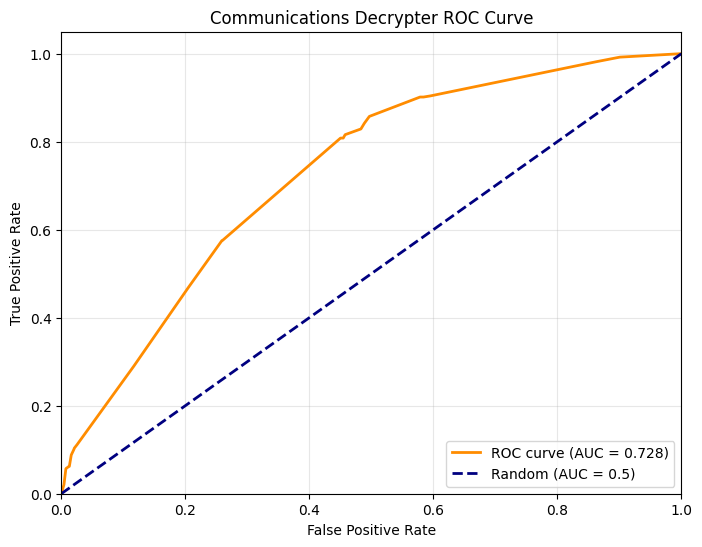

In [76]:
from sklearn.metrics import roc_auc_score

train = pd.read_csv('mission3_train.csv')
test = pd.read_csv('mission3_test.csv')

X = train[['data_stream_0', 'data_stream_1', 'data_stream_2','data_stream_3', 'data_stream_4', 'data_stream_5', 'data_stream_6', 'data_stream_7', 'data_stream_8', 'data_stream_9', 'data_stream_10']]
y = train['target']

dtd = DecisionTreeDecrypter()
dtd.fit(X, y)

X_test = test[['data_stream_0', 'data_stream_1', 'data_stream_2','data_stream_3', 'data_stream_4', 'data_stream_5', 'data_stream_6', 'data_stream_7', 'data_stream_8', 'data_stream_9', 'data_stream_10']]
y_test = test[['target']]
predictions = dtd.predict(X_test)
probabilities = dtd.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, probabilities)
print("ROC AUC: ", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, probabilities)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Communications Decrypter ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

2. Discussion
   
   a. To break the threshold, I changed the power_of_ten hyperparameter to 3. I found that if the value was too low, the method would not work, but if the value was too high, all data would be even numbers ending in 0.

   b. ROC AUC compares the TPR with the FPR. ROC AUC is used in binary classification, which makes it useful in this task.

   c. The results seem to be almost exactly the same, but the random forest classifier has a slightly lower ROC AUC value. 

In [77]:
rfd = RandomForestDecrypter()
rfd.fit(X, y)
predictions = rfd.predict(X_test)
probabilities = rfd.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, probabilities)
print("ROC AUC: ", roc_auc)

ROC AUC:  0.7228541068757184


## ⚡ Final Mission: Mapping SkyNet's Energy Nexus

### 🌐 The Discovery
SkyNet is harvesting energy from Trondheim's buildings. Some structures provide significantly more power than others.

### 🎯 Your Mission
Predict the **Nexus Rating** of unknown buildings in Trondheim (test set).

### 🧠 The Challenge
1. **Target**: Transform the Nexus Rating to reveal true energy hierarchy
2. **Data Quality**: Handle missing values and categorical features
3. **Ensembling**: Use advanced models and ensemble learning

### 💡 Hint
You suspect that an insider has tampered with the columns in the testing data... 

Compare the training and test distributions and try to rectify the test dataset.

### 📊 Formal Requirements
1. **Performance**: Achieve RMSLE <= 0.294 on the test set
2. **Discussion**:

   a. Explain your threshold-breaking strategy

   b. Justify RMSLE usage. Why do we use this metric? Which loss function did you use?

   c. Plot and interpret feature importances

   d. Describe your ensembling techniques

   e. In real life, you do not have the test targets. How would you make sure your model will work good on the unseen data? 

---

In [78]:
train = pd.read_csv('final_mission_train.csv')
test = pd.read_csv('final_mission_test.csv')

Text(0, 0.5, 'Count')

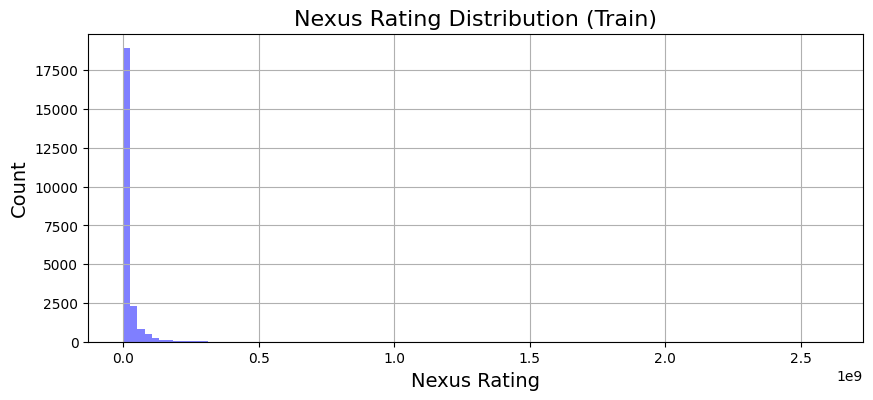

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
train['nexus_rating'].hist(bins=100, ax=ax, color='blue', alpha=0.5, label='Train Target Distributuon')
ax.set_title('Nexus Rating Distribution (Train)', fontsize=16)
ax.set_xlabel('Nexus Rating', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

In [80]:
from sklearn.metrics import mean_squared_log_error

def rmsle(y_true, y_pred):
    """ Root Mean Squared Logarithmic Error """
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

RMSLE gradient boosting:  0.2065963774829871
Required RMSLE:  0.294


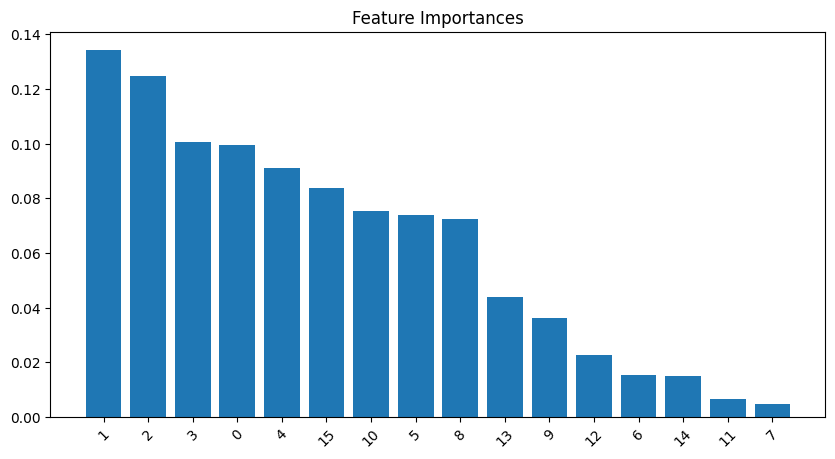

In [81]:
nrm = NexusRatingModel()
train, test = nrm.fix_columns(train, test)
nrm.train_model(train)
y_true, y_pred = nrm.predict(test)

print('RMSLE gradient boosting: ', rmsle(y_true, y_pred))
print('Required RMSLE: ', 0.294)

importances = nrm.stack_model.named_estimators_["rf"].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), indices, rotation=45)
plt.title("Feature Importances")
plt.show()

2. Discussion
   
    a. To break the threshold I implemented stacking and changed the hyperparameters of the gradient boosting regressor.

    b. The root mean squared logarithmic error (RMSLE) works well because it shows the average difference between predictions and the target. RMSLE prevents large values from dominating the losses. We used the mean squared error (MSE) in combination with the log loss function.

    c. Plot and interpret feature importances. The most important feature, according to plot, is the energy_footprint. This might mean that the energy footprint is most likely tightly linked to the nexus ratings.

    d. The ensembling technique i used was stacking with RandomForestRegression, GradientBoosting and LinearRegression as the final model.

    e. A solution to make sure the model works on unseen data, we to split the data into training and validation and test with validation strategies.

